In [1]:
import pandas as pd
import numpy as np
import sweetviz as sv

/home/nacho/Documents/CEIA/aprendizaje_profundo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Cargamos el dataset
df = pd.read_csv('dataset_compras.csv')

In [3]:
#Hacemos EDA con sweetviz
df_report = sv.analyze(df)
df_report.show_html("df_compras.html")

                                             |          | [  0%]   00:00 -> (? left)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report df_compras.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### Observaciones EDA
Al observar histrogramas de cada feature del dataset original vemos que en las variables categoricas no hay un serio desbalance. Por otro lado, en la unica variable numerica 'Purchase' hay un sesgo hacia la derecha pero no presenta outliers.

Por otro lado, los unicos faltantes corresponden a `Product Subcategory 1` (23%) y `Product Subcategory 2` (58%). Que seran imputados a 0 dando a entender que no se cuenta con informacion de los mismos. Product_Subcategory_2 sera descartada por su alta proporcion de faltantes.

Considerando que se desea definir en cierta forma al usuario para predecir su promedio de compra, las features que quiza mas relevante sean:
- Age
- Gender
- Marital Status
- City_Category
- Stay_In_Current_City_Years

Ademas de estas, seria provechoso tener una nocion de las tendencias de consumo del cliente, para ello se propone crear las siguientes features
- Favourite_Product: Producto favorito (moda de Product_ID por usuario)
- Favourite_Category: Categoria favorita (moda de Product_Category por usuario)
- Favourite_Subcategory: Subcategoria favorita (moda de Product_Subcategory_1 por usuario)

Finalmente se debera agregar el promedio de compra del cliente ya que sera nuestra variable target.

Se crea nueva tabla llamada `dataset_client.csv` que se forme a partir de `dataset_compras.csv` e incorpore todo el tratamiento mencionado  



In [4]:
client_df = df[['User_ID']].drop_duplicates().reset_index(drop=True)

purchase_mean_map = df.groupby('User_ID')['Purchase'].mean()
user_count_map = df.groupby('User_ID')['Purchase'].count()
fav_cat_map = df.groupby('User_ID')['Product_Category'].agg(lambda x: x.mode()[0])
fav_prod_map = df.groupby('User_ID')['Product_ID'].agg(lambda x: x.mode()[0])
fav_subcat_map = df.groupby('User_ID')['Product_Subcategory_1'].agg(lambda x: x.mode()[0])
age_map = df.groupby('User_ID')['Age'].agg(lambda x: x.mode()[0])
gender_map = df.groupby('User_ID')['Gender'].agg(lambda x: x.mode()[0])
marital_map = df.groupby('User_ID')['Marital_Status'].agg(lambda x: x.mode()[0])
city_map = df.groupby('User_ID')['City_Category'].agg(lambda x: x.mode()[0])
stay_map = df.groupby('User_ID')['Stay_In_Current_City_Years'].agg(lambda x: x.mode()[0])

client_df['User_Age'] = client_df['User_ID'].map(age_map)
client_df['User_Gender'] = client_df['User_ID'].map(gender_map)
client_df['User_Marital_Status'] = client_df['User_ID'].map(marital_map)
client_df['User_City_Category'] = client_df['User_ID'].map(city_map)
client_df['User_Stay'] = client_df['User_ID'].map(stay_map)
client_df['User_Favourite_Category'] = client_df['User_ID'].map(fav_cat_map)
client_df['User_Favourite_Product'] = client_df['User_ID'].map(fav_prod_map)
client_df['User_Favourite_Subcategory'] = client_df['User_ID'].map(fav_subcat_map)
client_df['Purchase_Avg'] = client_df['User_ID'].map(purchase_mean_map)
client_df = client_df.drop(columns='User_ID')


In [5]:
client_df.to_csv('dataset_client.csv', index=False)
client_df.head()

,User_Age,User_Gender,User_Marital_Status,User_City_Category,User_Stay,User_Favourite_Category,User_Favourite_Product,User_Favourite_Subcategory,Purchase_Avg
0,46-50,F,1,B,1,3,P00007791,45.0,6895.142857
1,36-45,M,0,A,3,12,P00073174,27.0,4666.857143
2,36-45,M,1,A,5+,3,P00082464,36.0,11071.771429
3,36-45,M,1,A,1,3,P00027480,24.0,13216.360000
4,46-50,M,1,A,5+,3,P00006469,42.0,8613.562500


In [6]:
client_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7432 entries, 0 to 7431
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_Age                    7432 non-null   str    
 1   User_Gender                 7432 non-null   str    
 2   User_Marital_Status         7432 non-null   int64  
 3   User_City_Category          7432 non-null   str    
 4   User_Stay                   7432 non-null   str    
 5   User_Favourite_Category     7432 non-null   int64  
 6   User_Favourite_Product      7432 non-null   str    
 7   User_Favourite_Subcategory  7432 non-null   float64
 8   Purchase_Avg                7432 non-null   float64
dtypes: float64(2), int64(2), str(5)
memory usage: 522.7 KB


In [7]:
# Realizamos nuevamente el EDA pero con users
client_report = sv.analyze(client_df,target_feat='Purchase_Avg')
client_report.show_html("df_client.html")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report df_client.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### Observaciones EDA

Tras realizar nuevamente el EDA observamos que no tenemos faltantes ni outliers. Ademas la distribucion de la variables categoricas sigue siendo balanceada. 

Un punto intersante es que la matriz de asociaciones de sweetviz marca relaciones entre todos los feautres y el target, indicando que posiblimente estos puedan ayudar a predecirla. 

Por utlimo se analizo la cardinalidad de las variables categoricas para decidir que tipo de encoding realizar.
- User_Age: (7) OHE
- User_Gender: (2) OHE
- User_Marital_Status: (2) OHE
- User_City_Category: (3) OHE
- User_Stay: (5) OHE
- User_Favourite_Category: (20) Target Encoding
- User_Favourite_Product: (1214) Target Encoding
- User_Favourite_Category: (33) Target Encoding

Las features de cardinalidad media-alta usaran Target Encoding, procurando ajustar con los datos de entrenamiento para no producir leakage.

Se aplicara tambien estandarizacion a las variables a las que se les produjo Target Encoding

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.model_selection import train_test_split
X = client_df.drop(columns='Purchase_Avg')
y = client_df['Purchase_Avg']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)
ohe_cols = [
    'User_Age',
    'User_Gender',
    'User_Marital_Status',
    'User_City_Category',
    'User_Stay',
    'User_Favourite_Category',
]
target_enc_cols = [
    'User_Favourite_Category',
    'User_Favourite_Subcategory',
    'User_Favourite_Product'
]

preprocessor = ColumnTransformer(
    transformers=[ 
        ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols),
        ('target_enc_scaled', Pipeline([
            ('encoder', TargetEncoder(random_state=42)),
            ('scaler', StandardScaler())
        ]), target_enc_cols),
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

pipeline.set_output(transform="pandas")

pipeline.fit(X_train, y_train)
X_train = pipeline.transform(X_train)
X_test = pipeline.transform(X_test)
X_val = pipeline.transform(X_val)


/home/nacho/Documents/CEIA/aprendizaje_profundo/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [9]:
X_train.shape

(5350, 42)

### Definicion del modelo MLP
Se propone un modelo de las siguientes caracteristicas:
- 3 capas ocultas (128 neuronas, 64 neuronas, 32 neuronas)
- Funcion de activacion GeLU, con la justificacion de que la red es pequena y los datos de entrenamiento son escasos, por los que sus perjucicios relacionados a la complejidad computacional no son significativos.
- La funcion de costo sera el RMSE, ya que tendremos un numero mas interpretable que MSE al estar en las mismas unidades que nuestra variable target a la vez que penalizara con mas severidad que MAE a los erroes grandes. 
- Para el optimizador se utilizara Adam Mini Batch ya que suele ser mas insensible al learning rate. Se selecciona un Batch Size de 256
- Para el learning rate se propone realizar pruebas sobre un set de validacion y determinarlo de manera empirica.

In [ ]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# =======================
# Configuración inicial
# =======================
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = torch.tensor(X_train.values, dtype=torch.float32).to(device)
X_test  = torch.tensor(X_test.values, dtype=torch.float32).to(device)
X_val  = torch.tensor(X_val.values, dtype=torch.float32).to(device)

y_train = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1).to(device)
y_test  = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1).to(device)
y_val  = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1).to(device)

input_layer_size = X_train.shape[1]



In [44]:
# Learning Rates
learning_rates = [0.5, 0.1, 1e-2, 1e-4]
batch_size = 256
epochs = 100
nn_val_results = {}

In [48]:
for lr in learning_rates:
    model = nn.Sequential(
        nn.Linear(input_layer_size, 128),
        nn.GELU(),
        nn.Linear(128, 64),
        nn.GELU(),
        nn.Linear(64, 32),
        nn.GELU(),
        nn.Linear(32, 1),
    ).to(device)

    ds = TensorDataset(X_train, y_train)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse_loss = nn.MSELoss()

    # =======================
    # Entrenamiento
    # =======================
    nn_val_results[lr] = {
        'train_loss_hist' : [],
        'r2_hist' : [],
        'val_loss_hist' : [],
        'model' : None,
    }

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for xb, yb in dl:
            yhat = model(xb)
            loss = torch.sqrt(mse_loss(yhat, yb))  # RMSE

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()

        # Promedio de pérdidas por época
        epoch_loss /= len(dl)
        nn_val_results[lr]['train_loss_hist'].append(epoch_loss)

        # Evaluación de R² por época
        model.eval()
        with torch.no_grad():
            yhat_val = model(X_val)
            y_true_np = y_val.view(-1).cpu().numpy()
            y_pred_np = yhat_val.view(-1).cpu().numpy()
            r2 = r2_score(y_true_np, y_pred_np)
            nn_val_results[lr]['r2_hist'].append(r2)
            val_loss = torch.sqrt(mse_loss(yhat_val, y_val)).cpu().numpy()
            nn_val_results[lr]['val_loss_hist'].append(val_loss)
        model.train()
        nn_val_results[lr]['model'] = model

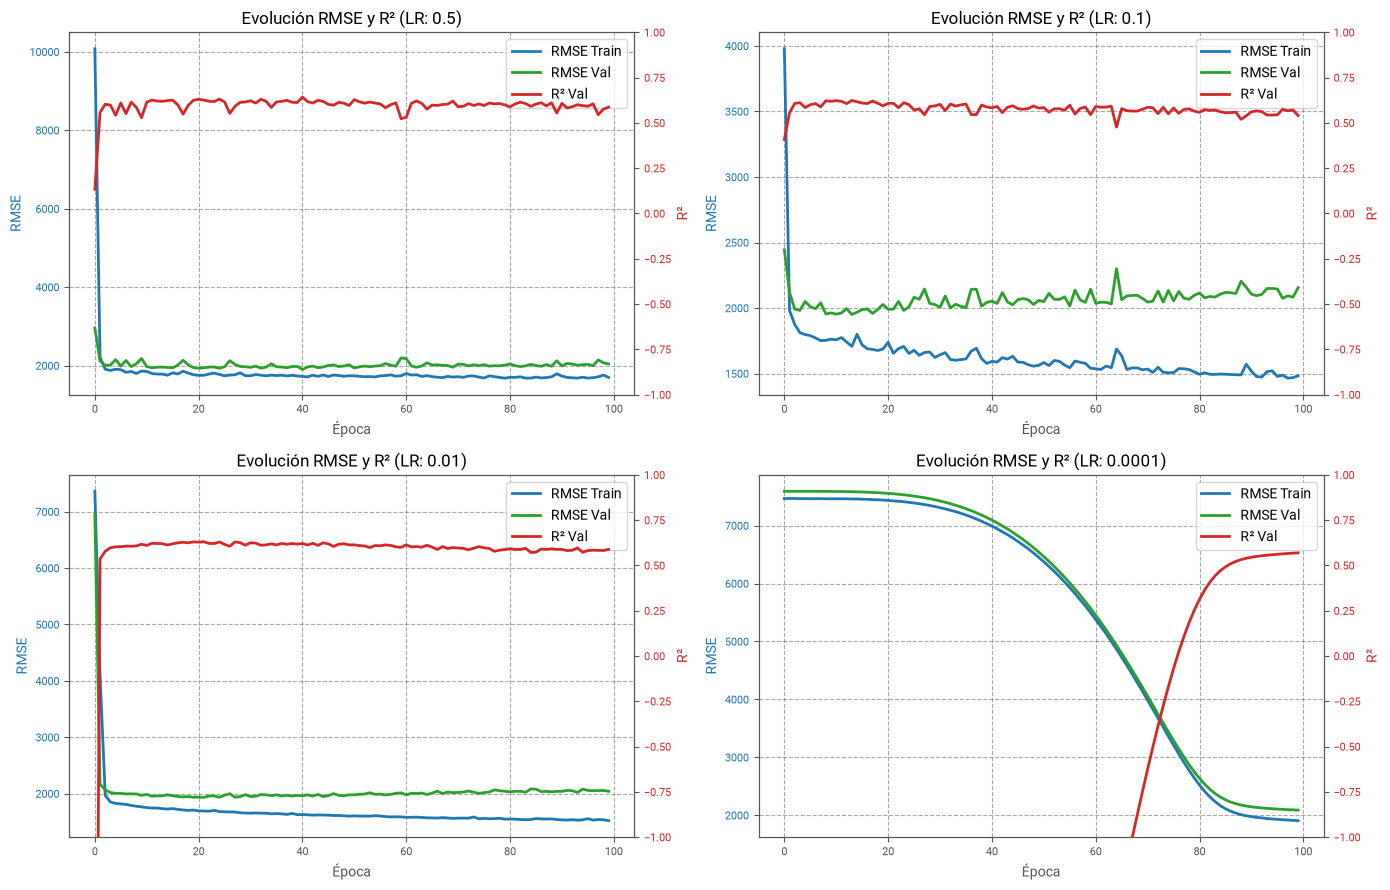

In [49]:
# Comparacion entre learning rates
fig, axs = plt.subplots(2, 2, figsize=(14, 9))

for ax1, lr in zip(axs.flat, nn_val_results.keys()):
    ax1.plot(nn_val_results[lr]['train_loss_hist'], color='tab:blue', label='RMSE Train', linewidth=2)
    ax1.plot(nn_val_results[lr]['val_loss_hist'], color='tab:green', label='RMSE Val', linewidth=2)
    
    ax1.set_xlabel("Época")
    ax1.set_ylabel("RMSE", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(nn_val_results[lr]['r2_hist'], color='tab:red', label='R² Val', linewidth=2)
    ax2.set_ylabel("R²", color='tab:red')
    ax2.set_ylim(-1,1)
    ax2.tick_params(axis='y', labelcolor='tab:red')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    ax1.set_title(f"Evolución RMSE y R² (LR: {lr})")

plt.tight_layout()
plt.show()


### Eleccion de learning rate

Tras observar el comportamiento del modelo con los distintos valores, vemos como el de 0.5 converge mas rapido que los demas, en alrededor de 20 epocas. El valor al que converge es un RMSE de entrenamiento similar al de los demas leaning rates, pero que presenta menor error sobre el set de validacion. Por estos 2 motivos es que se selecciona dicho valor.

In [59]:
# =======================
# Evaluación final
# =======================
model = nn_val_results[0.5]['model']
model.eval()
with torch.no_grad():
    yhat = model(X_test)
    mse = mse_loss(yhat, y_test).item()
    rmse = mse ** 0.5
    y_true_np = y_test.view(-1).cpu().numpy()
    y_pred_np = yhat.view(-1).cpu().numpy()
    r2 = r2_score(y_true_np, y_pred_np)

print(f"Resultados finales: RMSE={rmse:.4f}  R2={r2:.4f}")

Resultados finales: RMSE=2061.6844  R2=0.6187


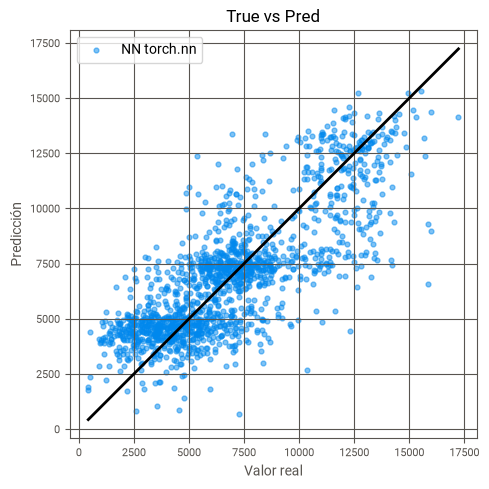

In [60]:
# Gráfica True vs Pred
plt.figure(figsize=(5,5))
plt.scatter(y_true_np, y_pred_np, s=12, alpha=0.5, label="NN torch.nn")
m = float(min(y_true_np.min(), y_pred_np.min()))
M = float(max(y_true_np.max(), y_pred_np.max()))
plt.plot([m, M], [m, M], linewidth=2, color="black")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("True vs Pred")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Conclusiones

A partir de registros de ventas se armo un nuevo dataset con informacion de los clientes con el fin de predecir el gasto promedio de aquellos que cuentan con pocas registros. Esto implico crear features, limpiar los datos, codificarlas, escalarlas y procurar no incurrir en data leakeage entremedio. Las features que el modelo utilza son:
- User_Age
- User_Gender
- User_Marital_Status
- User_City_Category
- User_Stay
- User_Favourite_Category
- User_Favourite_Product
- User_Favourite_Subcategory
Por otro lado, la variable target es:
- Purchase_Avg

Una vez construido el dataset se armo el modelo MLP de la siguiente forma:
- 3 capas ocultas (128, 64 y 32 neuronas)
- Funcion de activacion GeLu
- Optimizador Adam Mini Batch, con batch size de 256
- Learning rate de 0.5
- Funcion de costo RMSE
- Entrenamiento de 100 epocas (20 hubiesen sido suficientes)

Las caracteristicas del modelo fueron seleccionadas de forma teorica a excepcion del learning rate que fue obtenido de forma empirica tras probar distintos valores sobre un set de validacion.

El desempeno del modelo sobre el set de Test fue:

| Metrica | Valor |
| -------- | -------- |
| $R^2$  |  0.62 |
| RMSE  |  2061.68 |

En cuanto al valor de $R^2$ no se logro alcanzar el 0,7 sugerido como criterio de buen desmepeno. Sin embargo el grafico de dispersion muestra que el modelo sigue de cierta forma la tendencia de la variable a predecir. 

Por otro lado, el valor obtenido de RMSE es dificl de estimar su significancia sin tener contexto del problema de negocio. Sin embargo, considerando que el desvio estandar de la variable a predecir es de 3300 aproximadamente, nuestro modelo predice considerablemente mejor que si solo usasmemos la media.
